# final report

### step1: 載入資料

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.model_selection import GridSearchCV


# Windows 內建支持中文的字體
# plt.rcParams['font.family'] = 'Microsoft JhengHei'
# plt.rcParams['axes.unicode_minus'] = False

# Mac 內建的支援中文的字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# 或者是 plt.rcParams['font.sans-serif'] = ['PingFang TC']

# 解決負號 ('-') 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 載入資料，切分資料(確認是不是要獨立切出一個驗證集)

# ── 1. 載入資料，排除序號欄 ────────────────────────────────
df = pd.read_csv('selected_data_6m_0514.csv')
df = df.drop(columns=['序號'])

# ── 2. 特徵與目標變數（Y 在最後，直接取欄名）──────────────
X = df.drop(columns=['Y_事故嚴重度']).fillna(0)
y = df['Y_事故嚴重度']

features = X.columns.tolist()
print(f"特徵數量：{len(features)}")
print(f"特徵清單：{features}")

# ── 3. 切分訓練集 / 測試集 ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n訓練集 Y 分布：")
print(y_train.value_counts())
print(f"\n測試集 Y 分布：")
print(y_test.value_counts())
print(f"\n訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")

特徵數量：51
特徵清單：['GPS座標X', 'GPS座標Y', 'is_evening_rush', 'is_morning_rush', 'is_night', 'is_weekend', 'time_period_daytime', 'time_period_evening_rush', 'time_period_morning_rush', '事故位置_1', '事故位置_2', '事故位置_8', '事故位置_9', '分向設施_1', '分向設施_10', '分向設施_5', '區_中區', '區_北區', '區_北屯區', '區_南區', '區_后里區', '區_大雅區', '區_沙鹿區', '區_潭子區', '區_烏日區', '區_西屯區', '區_豐原區', '天候_7', '快慢車道間_1', '快慢車道間_4', '快慢車道間_5', '快車道或一般車道間_4', '快車道或一般車道間_5', '號誌動作_4', '號誌種類_2', '號誌種類_3', '號誌種類_4', '號誌種類_缺失', '路面狀態_5', '路面缺陷_4', '路面缺陷_其他', '路面邊線_1', '路面邊線_2', '道路型態_11', '道路型態_13', '道路型態_3', '道路型態_4', '道路照明設備_1', '道路照明設備_2', '道路照明設備_3', '道路速限']

訓練集 Y 分布：
Y_事故嚴重度
1    16176
0    12933
Name: count, dtype: int64

測試集 Y 分布：
Y_事故嚴重度
1    4045
0    3233
Name: count, dtype: int64

訓練集：29109 筆，測試集：7278 筆


## Logistic regression
### step 2: modeling

In [3]:
# 標準化資料

# 建立前處理器：把標準化放進 Pipeline，避免 cross-validation 時的資料洩漏

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── 只對連續型欄位做標準化 ─────────────────────────────────
continuous_cols = ['GPS座標X', 'GPS座標Y', '道路速限']

# 檢查連續欄位是否都存在，避免欄位名稱打錯導致後面報錯
missing_cols = [col for col in continuous_cols if col not in X_train.columns]
if len(missing_cols) > 0:
    raise ValueError(f"以下連續欄位不存在於 X_train 中：{missing_cols}")

# ColumnTransformer 會在每一次 fit / cross-validation 中，只用訓練資料估計平均數與標準差
preprocess = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), continuous_cols)
    ],
    remainder='passthrough'
)

print("前處理器建立完成！")
print("會被標準化的連續欄位：")
print(continuous_cols)

前處理器建立完成！
會被標準化的連續欄位：
['GPS座標X', 'GPS座標Y', '道路速限']


In [4]:
# 有 class_weight：使用 Pipeline 進行 Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# ── 1. 定義 Pipeline：標準化 + Logistic Regression ─────────
lr_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    ))
])

# 為了讓後面若有用到 model 這個名稱也能跑，保留同義變數
model = lr_pipe

# ── 2. 交叉驗證：直接丟原始 X_train，不要先手動標準化 ───────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    lr_pipe, X_train, y_train,
    cv=cv, scoring='recall', n_jobs=-1
)

cv_f1 = cross_val_score(
    lr_pipe, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("交叉驗證結果（訓練集）：")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ── 3. 訓練最終模型 ───────────────────────────────────────
lr_pipe.fit(X_train, y_train)
print("\n模型訓練完成！")

交叉驗證結果（訓練集）：
  Recall : 0.5297 ± 0.0110
  F1     : 0.5695 ± 0.0077

模型訓練完成！


### step3 : Hyperparameter

In [5]:
# 調超參數 Grid Search
# 注意：因為現在模型包在 Pipeline 裡，所以參數名稱前面要加 model__

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# ── 定義 Pipeline ─────────────────────────────────────────
lr_grid_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# ── 定義參數網格 ──────────────────────────────────────────
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__class_weight': ['balanced']
}

# ── Grid Search：用 F1-score 作為挑選標準 ───────────────────
grid_search = GridSearchCV(
    lr_grid_pipe,
    param_grid,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 直接使用原始 X_train，標準化會在 Pipeline 裡面完成
grid_search.fit(X_train, y_train)

# ── 整理結果 ──────────────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)

summary = results[[
    'param_model__C',
    'param_model__penalty',
    'param_model__class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]]

summary = summary.rename(columns={
    'param_model__C': 'C',
    'param_model__penalty': 'penalty',
    'param_model__class_weight': 'class_weight',
    'mean_test_score': 'F1-score（平均）',
    'std_test_score': 'F1-score（標準差）',
    'rank_test_score': '排名'
})

summary['F1-score（平均）'] = summary['F1-score（平均）'].round(4)
summary['F1-score（標準差）'] = summary['F1-score（標準差）'].round(4)

print("Grid Search 結果（以 F1-score 作為標準）：")
print(summary.sort_values('排名').to_string(index=False))

print("\n最佳參數：")
print(grid_search.best_params_)
print(f"最佳 F1-score（CV）：{grid_search.best_score_:.4f}")

# ── 直接取出已訓練好的最佳模型，不需要手動帶入參數再重新訓練 ──
best_lr_model = grid_search.best_estimator_
print("LR 最終模型訓練完成！")

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Grid Search 結果（以 F1-score 作為標準）：
     C penalty class_weight  F1-score（平均）  F1-score（標準差）  排名
100.00      l1     balanced        0.5715         0.0087   1
100.00      l2     balanced        0.5714         0.0088   2
 10.00      l1     balanced        0.5714         0.0087   3
  0.10      l2     balanced        0.5710         0.0092   4
 10.00      l2     balanced        0.5709         0.0088   5
  1.00      l2     balanced        0.5707         0.0096   6
  0.01      l2     balanced        0.5705         0.0082   7
  1.00      l1     balanced        0.5704         0.0099   8
  0.10      l1     balanced        0.5683         0.0099   9
  0.01      l1     balanced        0.5529         0.0064  10

最佳參數：
{'model__C': 100, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}
最佳 F1-score（CV）：0.5715
LR 最終模型訓練完成！


### step 4 : Evaluation

Logistic Regression 評估結果：
Accuracy  : 0.5636
Precision : 0.6242
Recall    : 0.5399
F1-score  : 0.5790
ROC-AUC   : 0.5971
PR-AUC    : 0.6428

Classification Report:
              precision    recall  f1-score   support

         非致命       0.51      0.59      0.55      3233
          致命       0.62      0.54      0.58      4045

    accuracy                           0.56      7278
   macro avg       0.57      0.57      0.56      7278
weighted avg       0.57      0.56      0.56      7278


Confusion Matrix:
[[1918 1315]
 [1861 2184]]


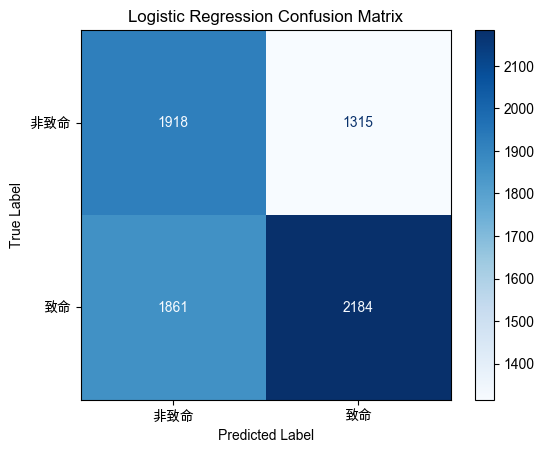

In [6]:
# 各項指標
# ── Logistic Regression 最終模型評估 ─────────────────────

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,ConfusionMatrixDisplay
)

# 預測類別與機率
y_pred = best_lr_model.predict(X_test)
y_prob = best_lr_model.predict_proba(X_test)[:, 1]

# 儲存 LR 評估指標，後面 RF 比較會用到
lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob)
}

print("Logistic Regression 評估結果：")
for metric, value in lr_metrics.items():
    print(f"{metric:<10}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['非致命', '致命']
))


# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm_lr = confusion_matrix(y_test, y_pred)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=['非致命', '致命']
)

disp_lr.plot(cmap='Blues', values_format='d')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [7]:
import numpy as np

# LR 輸出機率值
lr_prob = best_lr_model.predict_proba(X_test)[:, 1]

# 設定兩個門檻
low_threshold = 0.3
high_threshold = 0.7

# 根據兩個門檻設定決策邏輯
# 如果機率 >= 0.6 標記為 '致命' (或 1)
# 如果機率 <= 0.4 標記為 '非致命' (或 0)
# 介於兩者之間標記為 '需人工確認' (或 2)
conditions = [
    (lr_prob >= high_threshold),
    (lr_prob <= low_threshold)
]
choices = ['致命', '非致命']
# np.select 會根據條件給定標籤，預設為 '需人工確認'
predictions = np.select(conditions, choices, default='需人工確認')

lr_result = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': lr_prob,
    'prediction': predictions
})

print(lr_result.head(10))
lr_result.to_csv('lr_prob.csv', index=False)


   y_true    y_prob prediction
0       1  0.637723      需人工確認
1       0  0.546173      需人工確認
2       0  0.540081      需人工確認
3       0  0.425339      需人工確認
4       0  0.475436      需人工確認
5       0  0.446648      需人工確認
6       1  0.470251      需人工確認
7       1  0.334135      需人工確認
8       0  0.518787      需人工確認
9       1  0.460224      需人工確認


In [8]:
threshold = 0.4  # 可以調整這個數值

y_pred_lr_custom = (lr_prob >= threshold).astype(int)

from sklearn.metrics import classification_report, accuracy_score
print(f"門檻：{threshold}")
print(classification_report(y_test, y_pred_lr_custom, target_names=['non-fatal', 'fatal']))

門檻：0.4
              precision    recall  f1-score   support

   non-fatal       0.61      0.10      0.17      3233
       fatal       0.57      0.95      0.71      4045

    accuracy                           0.57      7278
   macro avg       0.59      0.52      0.44      7278
weighted avg       0.59      0.57      0.47      7278



In [9]:
# 尋找不同的門檻值

thresholds = np.arange(0.1, 0.9, 0.05)

print(f"{'='*55}")
print("LR 門檻掃描")
print(f"{'='*55}")
print(f"{'Threshold':>10}  {'Recall':>8}  {'Precision':>10}  {'F1':>8}")
print(f"{'-'*55}")
for t in thresholds:
    y_pred_t = (lr_prob >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"{t:>10.2f}  {r:>8.4f}  {p:>10.4f}  {f1:>8.4f}")

LR 門檻掃描
 Threshold    Recall   Precision        F1
-------------------------------------------------------
      0.10    1.0000      0.5570    0.7155
      0.15    1.0000      0.5571    0.7155
      0.20    1.0000      0.5571    0.7155
      0.25    1.0000      0.5572    0.7156
      0.30    0.9990      0.5583    0.7163
      0.35    0.9906      0.5613    0.7166
      0.40    0.9493      0.5686    0.7112
      0.45    0.8022      0.5913    0.6808
      0.50    0.5399      0.6242    0.5790
      0.55    0.2865      0.6646    0.4004
      0.60    0.1211      0.7143    0.2071
      0.65    0.0554      0.7442    0.1031
      0.70    0.0269      0.7676    0.0521
      0.75    0.0106      0.8431    0.0210
      0.80    0.0064      0.9630    0.0128
      0.85    0.0044      1.0000    0.0089


### step5: Interpretation

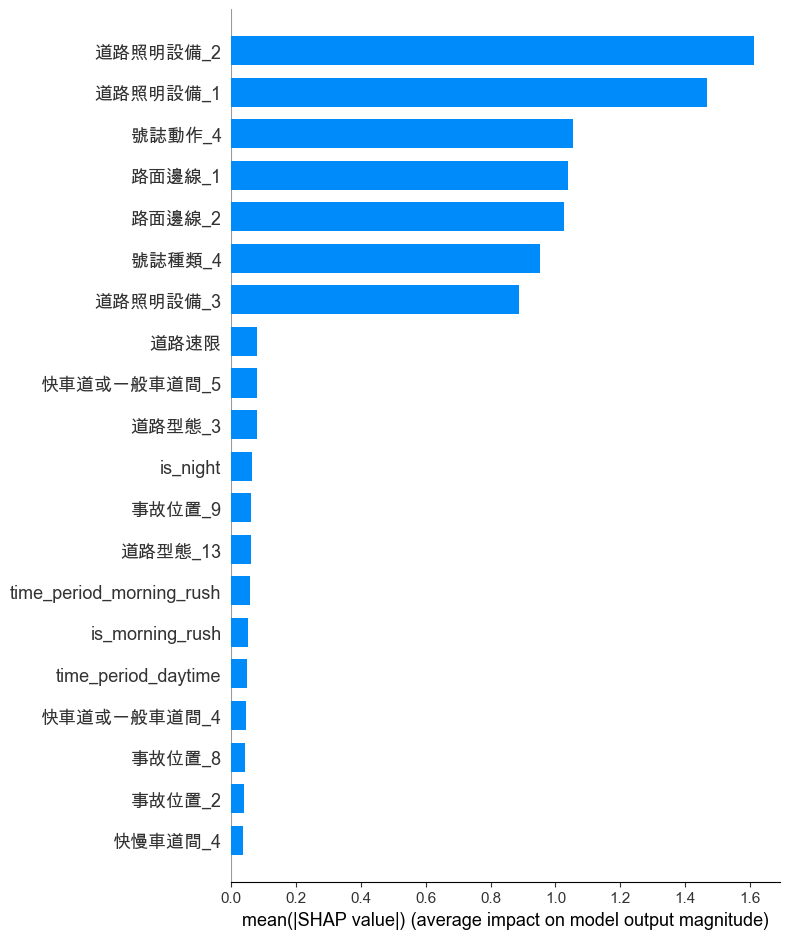

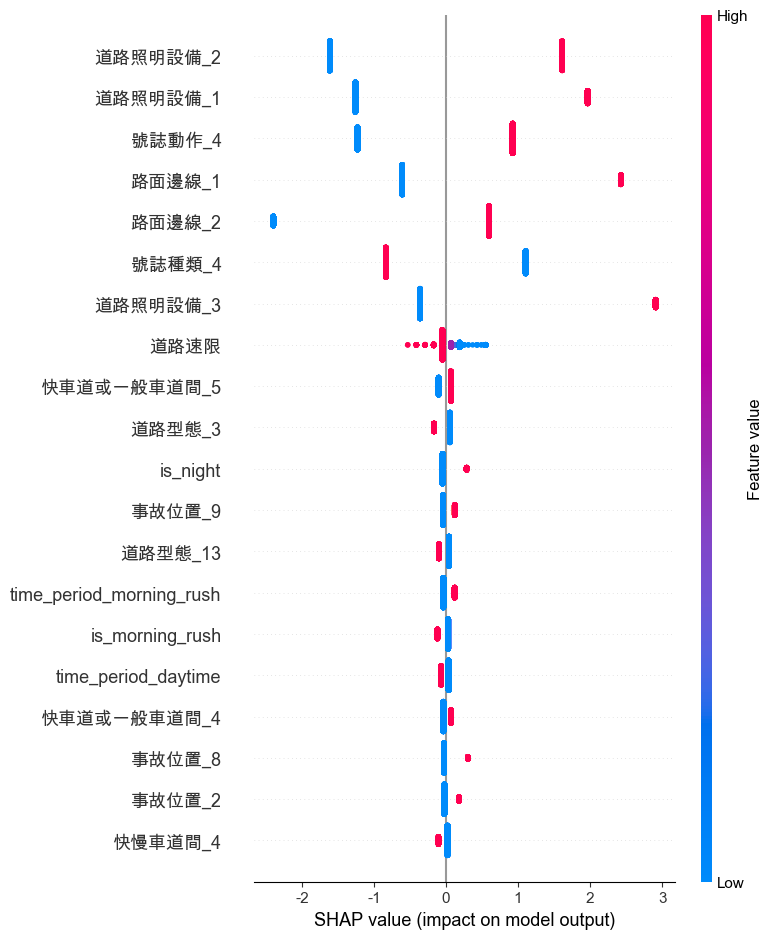

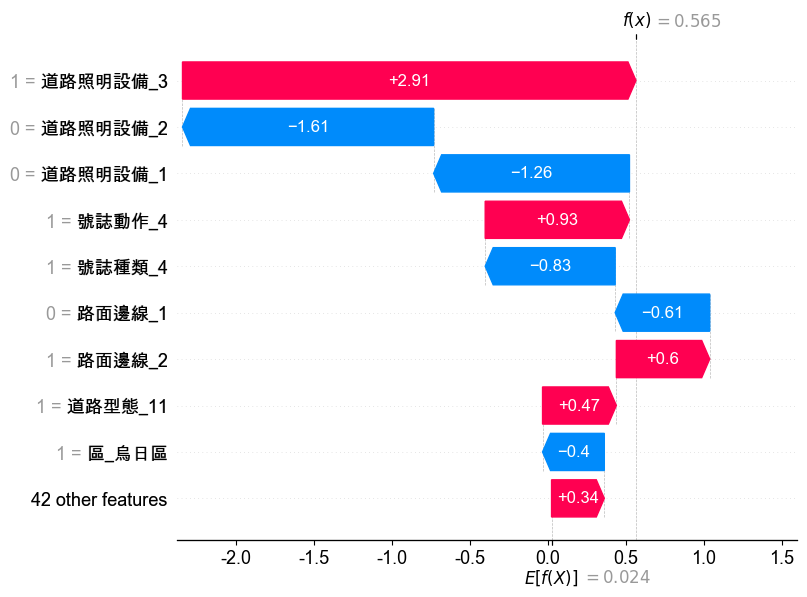

In [10]:
import shap

# ── 1. 從 Pipeline 取出已訓練好的前處理器與 LR 模型 ────────
fitted_preprocess = best_lr_model.named_steps['preprocess']
fitted_lr = best_lr_model.named_steps['model']

# ColumnTransformer 的輸出順序：先 continuous_cols，再 passthrough 欄位
passthrough_cols = [col for col in X_train.columns if col not in continuous_cols]
lr_shap_features = continuous_cols + passthrough_cols

# 將 X_train / X_test 轉成 LR 真正吃進去的標準化後資料
X_train_lr_shap = pd.DataFrame(
    fitted_preprocess.transform(X_train),
    columns=lr_shap_features,
    index=X_train.index
)

X_test_lr_shap = pd.DataFrame(
    fitted_preprocess.transform(X_test),
    columns=lr_shap_features,
    index=X_test.index
)

# ── 2. 建立 SHAP Explainer ────────────────────────────────
explainer = shap.LinearExplainer(fitted_lr, X_train_lr_shap)
shap_values = explainer.shap_values(X_test_lr_shap)

# ── 3. Summary Bar Plot：全局特徵重要性 ──────────────────
shap.summary_plot(
    shap_values,
    X_test_lr_shap,
    feature_names=lr_shap_features,
    plot_type='bar',
    show=True
)

# ── 4. Beeswarm Plot：特徵影響方向 ───────────────────────
shap.summary_plot(
    shap_values,
    X_test_lr_shap,
    feature_names=lr_shap_features,
    show=True
)

# ── 5. Waterfall Plot：單一致命案例解析 ──────────────────
fatal_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fatal_idx],
        base_values=explainer.expected_value,
        data=X_test_lr_shap.iloc[fatal_idx],
        feature_names=lr_shap_features
    )
)

## Random forest
### step2 : modeling

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── 定義模型（RF 不需要標準化，直接用原始 X_train）────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# ── 10-fold 交叉驗證 ───────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    rf_model, X_train, y_train,
    cv=cv, scoring='recall', n_jobs=-1
)
cv_f1 = cross_val_score(
    rf_model, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("【預設參數】交叉驗證結果：")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ── 訓練完整模型 ───────────────────────────────────────────
rf_model.fit(X_train, y_train)
print("\n模型訓練完成！")

【預設參數】交叉驗證結果：
  Recall : 0.5561 ± 0.0125
  F1     : 0.5849 ± 0.0069

模型訓練完成！


### step3 : Hyperparameter 

In [12]:
# 超參數

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ── 定義 Random Forest 模型 ───────────────────────────────
rf_model = RandomForestClassifier(
    random_state=42
)

# ── 定義參數網格 ──────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

# ── Grid Search：用 F1-score 作為挑選標準 ───────────────────
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=10,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)

# ── 整理結果 ──────────────────────────────────────────────
results_rf = pd.DataFrame(grid_search_rf.cv_results_)

summary_rf = results_rf[[
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_class_weight',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]]

summary_rf = summary_rf.rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'param_min_samples_split': 'min_samples_split',
    'param_class_weight': 'class_weight',
    'mean_test_score': 'F1-score（平均）',
    'std_test_score': 'F1-score（標準差）',
    'rank_test_score': '排名'
})

summary_rf['F1-score（平均）'] = summary_rf['F1-score（平均）'].round(4)
summary_rf['F1-score（標準差）'] = summary_rf['F1-score（標準差）'].round(4)

print("Random Forest Grid Search 結果（以 F1-score 作為標準）：")
print(summary_rf.sort_values('排名').to_string(index=False))

print("\n最佳參數：")
print(grid_search_rf.best_params_)
print(f"最佳 F1-score（CV）：{grid_search_rf.best_score_:.4f}")

# ── 直接取出已訓練好的最佳模型，不需要手動帶入參數再重新訓練 ──
best_rf_model = grid_search_rf.best_estimator_
print("RF 最終模型訓練完成！")

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Random Forest Grid Search 結果（以 F1-score 作為標準）：
 n_estimators  max_depth  min_samples_split class_weight  F1-score（平均）  F1-score（標準差）  排名
          200          4                  2     balanced        0.5907         0.0081   1
          200          4                 10     balanced        0.5904         0.0084   2
          300          4                 10     balanced        0.5898         0.0083   3
          200          4                  5     balanced        0.5898         0.0084   4
          300          4                  5     balanced        0.5896         0.0077   5
          300          4                  2     balanced        0.5896         0.0075   6
          100          4                  2     balanced        0.5866         0.0092   7
          100          4                  5     balanced        0.5862         0.0096   8
          100          4                 10     balanced        0.5856         0

### step4: Evaluation

Random Forest 評估結果：
Accuracy  : 0.5687
Precision : 0.6193
Recall    : 0.5815
F1-score  : 0.5998
ROC-AUC   : 0.5948
PR-AUC    : 0.6439

Classification Report:
              precision    recall  f1-score   support

         非致命       0.51      0.55      0.53      3233
          致命       0.62      0.58      0.60      4045

    accuracy                           0.57      7278
   macro avg       0.57      0.57      0.57      7278
weighted avg       0.57      0.57      0.57      7278


Confusion Matrix:
[[1787 1446]
 [1693 2352]]


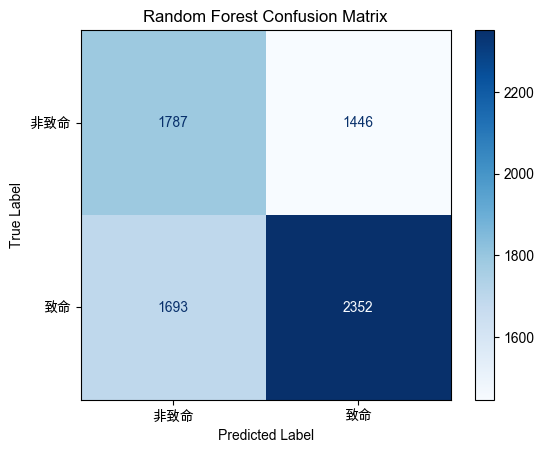

In [13]:
# ── Random Forest 最終模型評估 ─────────────────────

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# 預測類別與機率
y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

# 儲存 RF 評估指標
rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
    'PR-AUC': average_precision_score(y_test, y_prob_rf)
}

print("Random Forest 評估結果：")
for metric, value in rf_metrics.items():
    print(f"{metric:<10}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['非致命', '致命']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


# ── Random Forest Confusion Matrix ─────────────────────

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['非致命', '致命']
)

disp_rf.plot(cmap='Blues', values_format='d')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [14]:
# RF 輸出機率值

rf_prob = best_rf_model.predict_proba(X_test)[:, 1]

rf_result = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': rf_prob
})

print(rf_result.head(10))
rf_result.to_csv('rf_prob.csv', index=False)

   y_true    y_prob
0       1  0.603573
1       0  0.513889
2       0  0.502063
3       0  0.454256
4       0  0.512456
5       0  0.449521
6       1  0.510602
7       1  0.433733
8       0  0.478235
9       1  0.475255


In [15]:
threshold = 0.4

y_pred_rf_custom = (rf_prob >= threshold).astype(int)

print(f"門檻：{threshold}")
print(classification_report(y_test, y_pred_rf_custom, target_names=['non-fatal', 'fatal']))

門檻：0.4
              precision    recall  f1-score   support

   non-fatal       1.00      0.00      0.00      3233
       fatal       0.56      1.00      0.71      4045

    accuracy                           0.56      7278
   macro avg       0.78      0.50      0.36      7278
weighted avg       0.75      0.56      0.40      7278



In [16]:
# 尋找最佳門檻值

print(f"{'='*55}")
print("RF 門檻掃描")
print(f"{'='*55}")
print(f"{'Threshold':>10}  {'Recall':>8}  {'Precision':>10}  {'F1':>8}")
print(f"{'-'*55}")
for t in thresholds:
    y_pred_t = (rf_prob >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"{t:>10.2f}  {r:>8.4f}  {p:>10.4f}  {f1:>8.4f}")

RF 門檻掃描
 Threshold    Recall   Precision        F1
-------------------------------------------------------
      0.10    1.0000      0.5558    0.7145
      0.15    1.0000      0.5558    0.7145
      0.20    1.0000      0.5558    0.7145
      0.25    1.0000      0.5558    0.7145
      0.30    1.0000      0.5558    0.7145
      0.35    1.0000      0.5558    0.7145
      0.40    1.0000      0.5559    0.7145
      0.45    0.9792      0.5607    0.7131
      0.50    0.5815      0.6193    0.5998
      0.55    0.1155      0.7097    0.1986
      0.60    0.0232      0.8103    0.0452
      0.65    0.0015      0.8571    0.0030
      0.70    0.0000      0.0000    0.0000
      0.75    0.0000      0.0000    0.0000
      0.80    0.0000      0.0000    0.0000
      0.85    0.0000      0.0000    0.0000


### step5: Interpretation

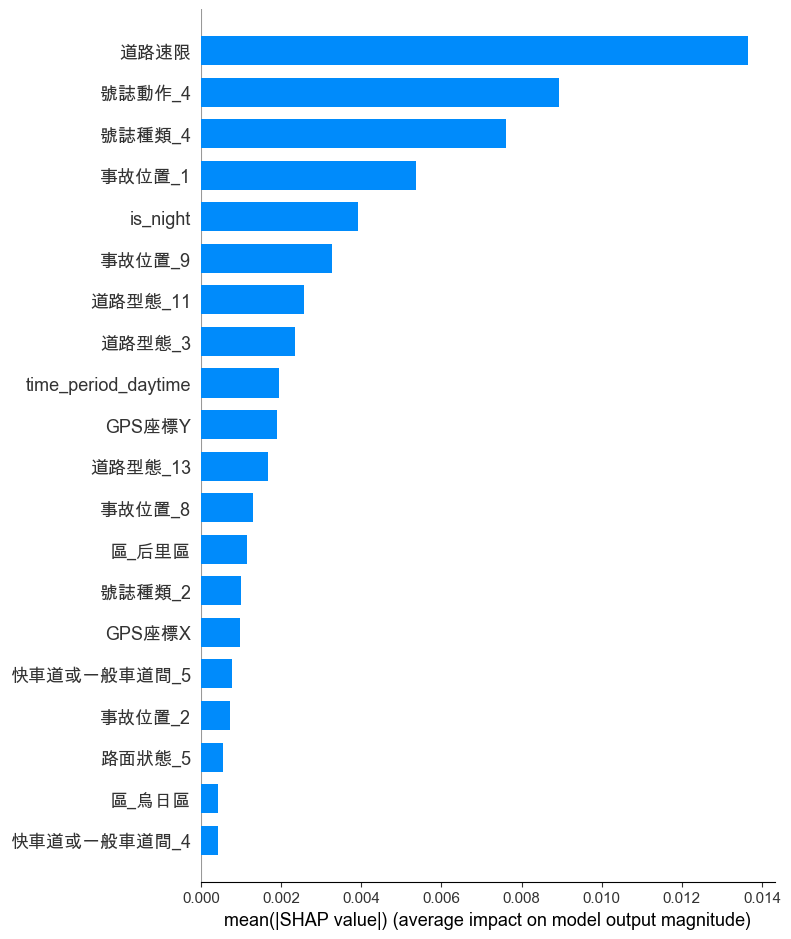

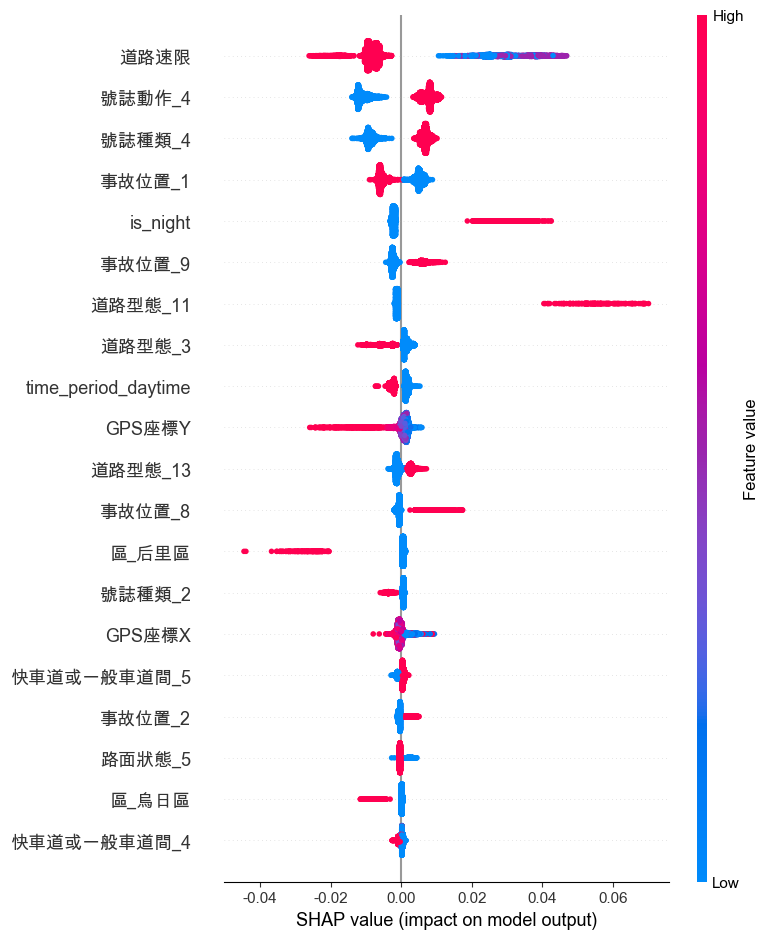

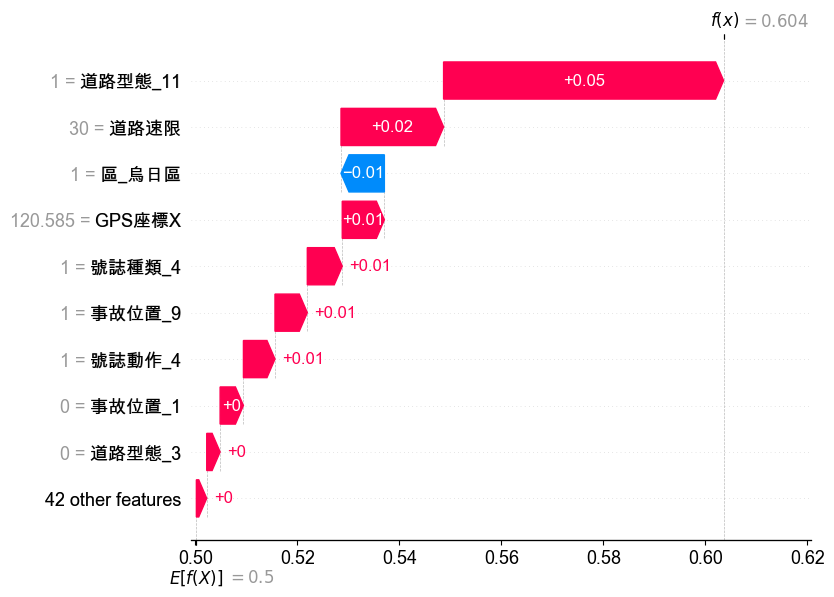

In [17]:
import shap
import numpy as np

# ── 1. 建立 SHAP Explainer（RF 用 TreeExplainer）─────────
explainer_rf = shap.TreeExplainer(best_rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

# TreeExplainer 對二元分類會回傳 list，取 class=1（致命）
shap_vals = shap_values_rf[:, :, 1] if shap_values_rf.ndim == 3 else shap_values_rf[1]

# ── 2. Summary Bar Plot：全局特徵重要性 ──────────────────
shap.summary_plot(
    shap_vals, X_test,
    feature_names=features,
    plot_type='bar',
    show=True
)

# ── 3. Beeswarm Plot：特徵影響方向 ───────────────────────
shap.summary_plot(
    shap_vals, X_test,
    feature_names=features,
    show=True
)

# ── 4. Waterfall Plot：單一致命案例解析 ──────────────────
fatal_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_vals[fatal_idx],
        base_values=explainer_rf.expected_value[1],
        data=X_test.iloc[fatal_idx],
        feature_names=features
    )
)

# Final Report - XGBoost

### Step 1: 載入資料與預處理
載入資料並進行訓練/測試集切分。**注意：本次實驗不使用 SMOTE。**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import warnings
import seaborn as sns

from IPython.display import display
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# ── 1. 載入資料，排除序號欄 ────────────────────────────────
df = pd.read_csv('processed_data.csv')
df = df.drop(columns=['序號'])

# ── 2. 特徵與目標變數 ──────────────────────────────────────
X = df.drop(columns=['Y_事故嚴重度']).fillna(0)
y = df['Y_事故嚴重度']

features = X.columns.tolist()
print(f"特徵數量：{len(features)}")

# ── 3. 切分訓練集 / 測試集 ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")
print(f"\n訓練集 Y 分布：\n{y_train.value_counts()}")
print(f"\n測試集 Y 分布：")
print(y_test.value_counts())
print(f"\n訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")

# Mac 內建的支援中文的字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# 或者是 plt.rcParams['font.sans-serif'] = ['PingFang TC']

# 解決負號 ('-') 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

# Windows 使用微軟正黑體 (Mac 若需使用請改為 'Arial Unicode MS' 或 'PingFang TC')
# plt.rcParams['font.family'] = 'Microsoft JhengHei'
# plt.rcParams['axes.unicode_minus'] = False

特徵數量：54
訓練集：15329 筆，測試集：3833 筆

訓練集 Y 分布：
Y_事故嚴重度
1    8580
0    6749
Name: count, dtype: int64

測試集 Y 分布：
Y_事故嚴重度
1    2146
0    1687
Name: count, dtype: int64

訓練集：15329 筆，測試集：3833 筆


### Step 2: Modeling (建立模型與交叉驗證)
由於沒有使用 SMOTE，我們必須利用 XGBoost 的 `scale_pos_weight` 參數來處理資料不平衡。
`scale_pos_weight` 的建議設定值為：**負樣本數 / 正樣本數**。

In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── 1. 計算正負樣本比例 ────────────────────────────────────
# y_train 中 0 為非致命(負樣本)，1 為致命(正樣本)
neg_count = len(y_train[y_train == 0])
pos_count = len(y_train[y_train == 1])
sp_weight = neg_count / pos_count
print(f"計算得到的 scale_pos_weight: {sp_weight:.4f}")

# ── 2. 定義初步 XGBoost 模型 ─────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=sp_weight, # 設定權重以處理不平衡
    eval_metric='logloss',
    n_jobs=-1
)

# ── 3. 10-fold 交叉驗證 ────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    xgb_model, X_train, y_train, # 直接使用原始 X_train, y_train
    cv=cv, scoring='recall', n_jobs=-1
)

cv_f1 = cross_val_score(
    xgb_model, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("\n【預設參數】10-fold 交叉驗證結果：")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ── 4. 訓練模型 ─────────────────────────────────────────
xgb_model.fit(X_train, y_train)
print("\n初步 XGBoost 模型訓練完成！")

計算得到的 scale_pos_weight: 0.7866

【預設參數】10-fold 交叉驗證結果：
  Recall : 0.5378 ± 0.0111
  F1     : 0.5778 ± 0.0099

初步 XGBoost 模型訓練完成！


### Step 3: Hyperparameter Tuning (超參數調優)
使用 GridSearchCV 尋找最佳的 `n_estimators`、`max_depth` 與 `learning_rate`。
確保在參數網格中包含我們計算出的 `scale_pos_weight`。

In [20]:
from sklearn.model_selection import GridSearchCV

# ── 1. 定義 XGBoost 參數網格 ──────────────────────────────
param_grid_xgb = {
    # 樹的數量：搭配較低的學習率，慢慢學比較穩
    'n_estimators': [100, 200, 300], 
    
    # 樹的深度：通常 3~7 之間表現最好，不容易死背
    'max_depth': [4, 6, 8], 
    
    # 學習率：0.2 已經算高了，建議加上 0.1 甚至更低的選項
    'learning_rate': [0.05, 0.1, 0.2], 
    
    # 正樣本權重：除了算出來的值，可以稍微給點彈性讓模型試試看
    'scale_pos_weight': [sp_weight] 
}

# ── 2. Grid Search (10 折交叉驗證) ─────────────────────────
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid_xgb,
    cv=10,              # 使用 10-fold CV
    scoring='f1',   # 以 f1 作為主要優化目標
    n_jobs=-1,
    verbose=1           # 執行時會顯示進度資訊
)

grid_search_xgb.fit(X_train, y_train)

# ── 3. 整理與輸出結果 ─────────────────────────────────────
results_xgb = pd.DataFrame(grid_search_xgb.cv_results_)

summary_xgb = results_xgb[[
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]]
summary_xgb = summary_xgb.rename(columns={
    'mean_test_score': 'F1（平均）',
    'std_test_score': 'F1（標準差）',
    'rank_test_score': '排名'
}).sort_values('排名')

print("\n超參數調優結果摘要 (前 5 名)：")
display(summary_xgb.head(5))

print(f"\n最佳參數：{grid_search_xgb.best_params_}")
print(f"最佳 F1（10-CV）：{grid_search_xgb.best_score_:.4f}")

# ── 4. 取得最佳模型 ───────────────────────────────────────
best_xgb = grid_search_xgb.best_estimator_
print("\n最佳 XGBoost 模型準備完畢！")

Fitting 10 folds for each of 27 candidates, totalling 270 fits

超參數調優結果摘要 (前 5 名)：


,param_n_estimators,param_max_depth,param_learning_rate,F1（平均）,F1（標準差）,排名
26,300,8,0.20,0.597975,0.015873,1
17,300,8,0.10,0.596138,0.010925,2
25,200,8,0.20,0.595713,0.013994,3
16,200,8,0.10,0.591659,0.010325,4
8,300,8,0.05,0.590473,0.009012,5



最佳參數：{'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 300, 'scale_pos_weight': 0.7865967365967366}
最佳 F1（10-CV）：0.5980

最佳 XGBoost 模型準備完畢！


### Step 4: Evaluation (模型評估)
在測試集上進行預測，並計算各項評估指標、分類報告以及繪製混淆矩陣。

指標                 XGBoost 最佳模型
Accuracy                 0.5531
Precision                0.5986
Recall                   0.6123
F1-score                 0.6054
ROC-AUC                  0.5712
PR-AUC                   0.6186

Classification Report:
              precision    recall  f1-score   support

     非致命 (0)       0.49      0.48      0.48      1687
      致命 (1)       0.60      0.61      0.61      2146

    accuracy                           0.55      3833
   macro avg       0.55      0.55      0.55      3833
weighted avg       0.55      0.55      0.55      3833



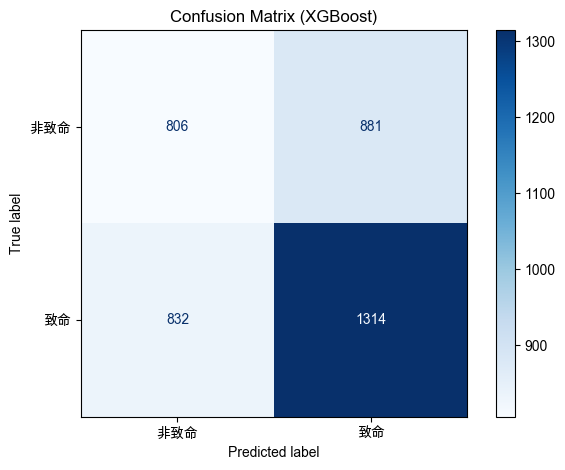

In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── 1. 在測試集上進行預測 ─────────────────────────────────
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# ── 2. 指標輸出 ──────────────────────────────────────────
print("=" * 45)
print(f"{'指標':<15} {'XGBoost 最佳模型':>15}")
print("=" * 45)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'F1-score':<15} {f1_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'ROC-AUC':<15} {roc_auc_score(y_test, y_prob_xgb):>15.4f}")
print(f"{'PR-AUC':<15} {average_precision_score(y_test, y_prob_xgb):>15.4f}")
print("=" * 45)

# ── 3. 分類報告 ──────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['非致命 (0)', '致命 (1)']))

# ── 4. 混淆矩陣 (Confusion Matrix) ────────────────────────
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['非致命', '致命'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.tight_layout()
plt.show()

### Step 5: Interpretation (模型解釋 - SHAP)
利用 SHAP (SHapley Additive exPlanations) 來拆解 XGBoost 模型，觀察特徵的全局重要性與單一案例的判斷邏輯。

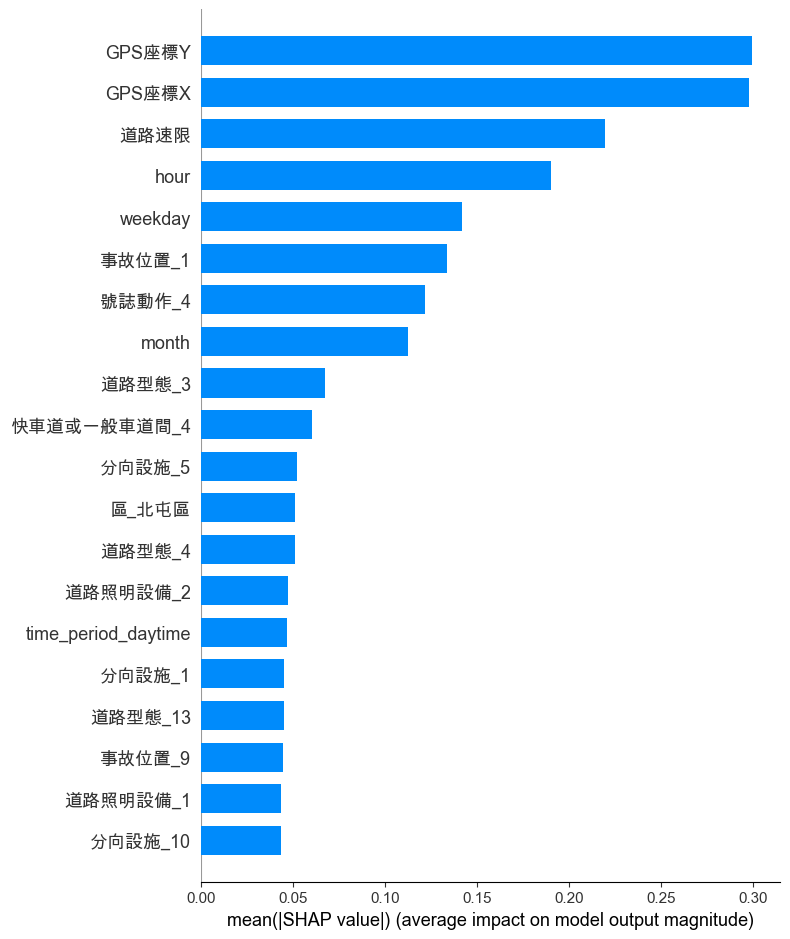

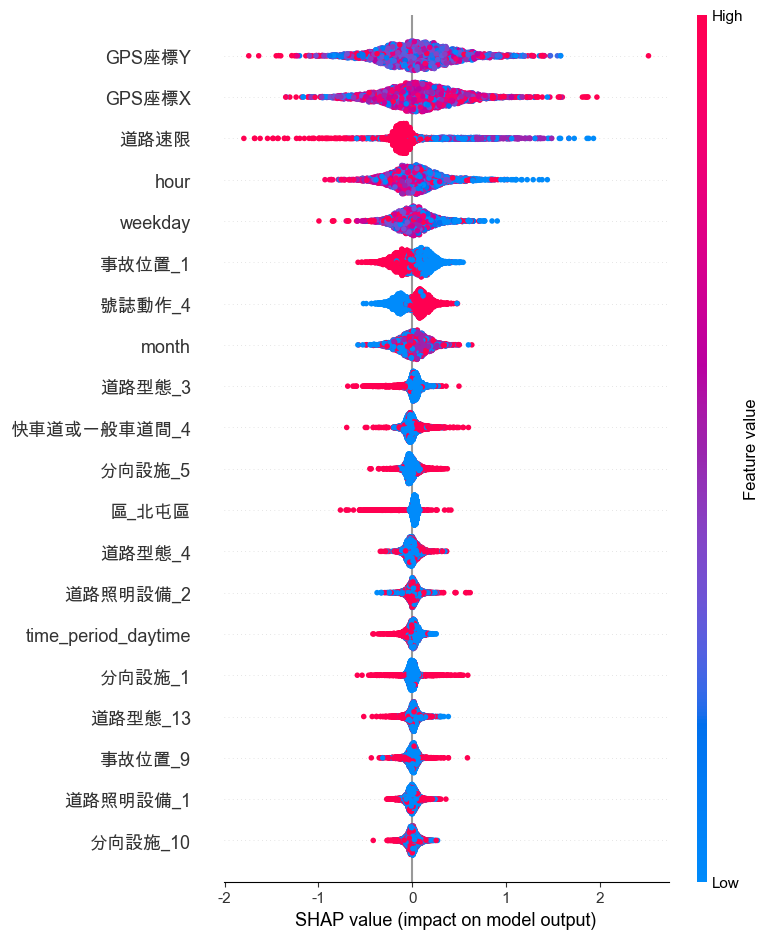

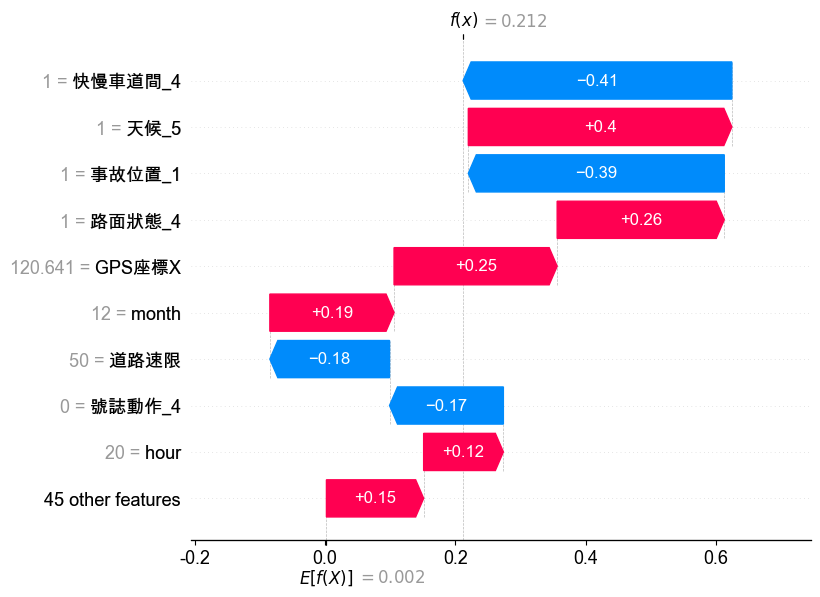

In [22]:
import shap

# ── 1. 建立 SHAP Explainer ────────────────────────────────
# XGBoost 屬於樹狀模型，使用 TreeExplainer
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# ── 2. Summary Bar Plot：全局特徵重要性 ──────────────────
shap.summary_plot(
    shap_values_xgb, X_test,
    feature_names=features,
    plot_type='bar',
    show=True
)

# ── 3. Beeswarm Plot：特徵影響方向 ───────────────────────
shap.summary_plot(
    shap_values_xgb, X_test,
    feature_names=features,
    show=True
)

# ── 4. Waterfall Plot：單一致命案例解析 ──────────────────
# 找出測試集中第一筆實際為「致命」(1) 的資料索引
fatal_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_xgb[fatal_idx],
        base_values=explainer_xgb.expected_value,
        data=X_test.iloc[fatal_idx],
        feature_names=features
    )
)

In [23]:
import numpy as np
import pandas as pd

# 1. 取得新進資料預測為「嚴重事故 (1)」的機率
# 假設 best_xgb 是您訓練好的模型，X_new 是即時的交通事故特徵
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# 2. 設定您的閾值 (Thresholds)
high_thresh = 0.7
med_thresh = 0.3

# 3. 定義邏輯條件與對應的策略
conditions = [
    (y_prob >= high_thresh),
    (y_prob >= med_thresh) & (y_prob < high_thresh),
    (y_prob < med_thresh)
]

risk_tiers = ['高風險', '中風險', '低風險']
actions = ['優先派遣警力或加強巡邏', '定期巡查', '維持現狀']

# 4. 產出決策報表
df_decisions = pd.DataFrame({'嚴重事故預測機率': y_prob})

# 加上 default='未知' 或其他字串，讓 NumPy 知道遇到例外時該填什麼字串
df_decisions['風險等級'] = np.select(conditions, risk_tiers, default='未知')
df_decisions['決策策略'] = np.select(conditions, actions, default='無動作')

# 檢視高風險且需要立即派警力的清單，並依機率高低排序
df_dispatch = df_decisions[df_decisions['風險等級'] == '高風險'].sort_values(by='嚴重事故預測機率', ascending=False)
display(df_dispatch.head(100))

,嚴重事故預測機率,風險等級,決策策略
3089,0.998885,高風險,優先派遣警力或加強巡邏
2259,0.998456,高風險,優先派遣警力或加強巡邏
502,0.996804,高風險,優先派遣警力或加強巡邏
2929,0.994156,高風險,優先派遣警力或加強巡邏
2570,0.994113,高風險,優先派遣警力或加強巡邏
...,...,...,...
3325,0.956333,高風險,優先派遣警力或加強巡邏
1803,0.956247,高風險,優先派遣警力或加強巡邏
1859,0.955799,高風險,優先派遣警力或加強巡邏
3676,0.955269,高風險,優先派遣警力或加強巡邏


## Step 6：模型預測結果

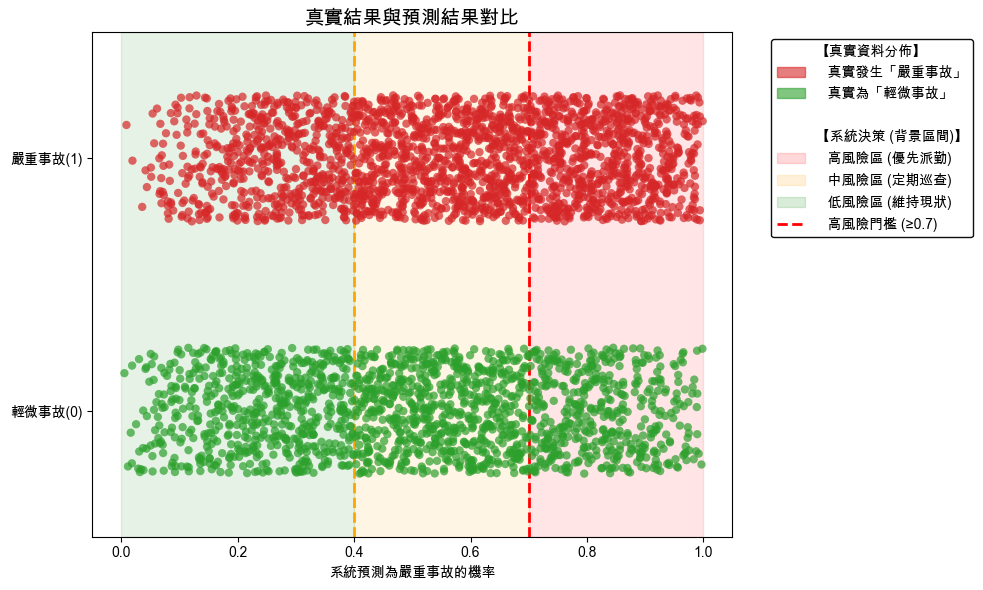

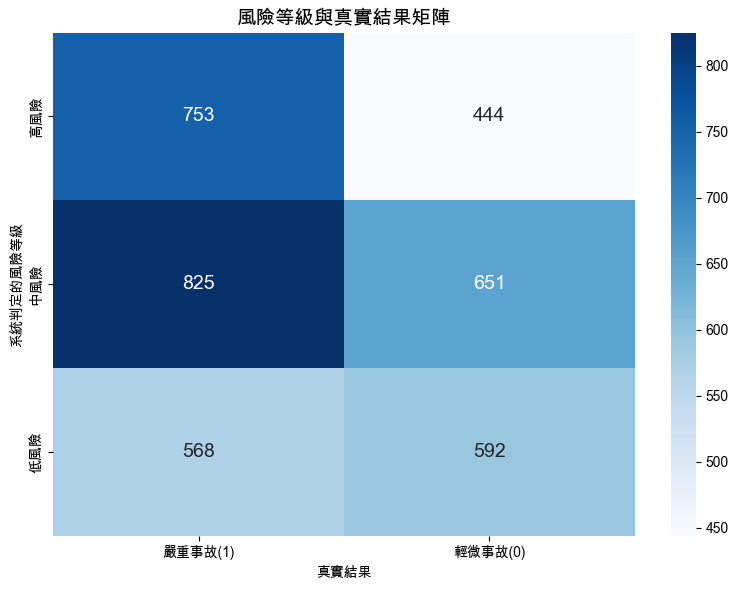


【案件決策與真實情況比對表 (依高風險排序)】


,嚴重事故預測機率,風險等級,決策策略,真實結果標籤
10045,0.998885,高風險,優先派遣警力,嚴重事故(1)
5751,0.998456,高風險,優先派遣警力,輕微事故(0)
11005,0.996804,高風險,優先派遣警力,輕微事故(0)
4621,0.994156,高風險,優先派遣警力,嚴重事故(1)
10295,0.994113,高風險,優先派遣警力,嚴重事故(1)
5992,0.993959,高風險,優先派遣警力,嚴重事故(1)
5766,0.993341,高風險,優先派遣警力,嚴重事故(1)
11650,0.992035,高風險,優先派遣警力,輕微事故(0)
11293,0.990899,高風險,優先派遣警力,嚴重事故(1)
9679,0.990844,高風險,優先派遣警力,嚴重事故(1)


In [24]:
# 設定支援中文的字體 (依您的作業系統調整，Windows通常用 'Microsoft JhengHei')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 取得預測機率
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# 2. 產出決策報表：新增「真實結果」欄位
df_decisions = pd.DataFrame({
    '嚴重事故預測機率': y_prob,
    '真實結果': y_test.values  # 放入真實的 0 或 1
}, index=y_test.index) # 保留原本測試集的 index 方便後續查閱異常案件

# 3. 設定閾值與決策邏輯(threshold)
high_thresh = 0.7
med_thresh = 0.4

conditions = [
    (df_decisions['嚴重事故預測機率'] >= high_thresh),
    (df_decisions['嚴重事故預測機率'] >= med_thresh) & (df_decisions['嚴重事故預測機率'] < high_thresh),
    (df_decisions['嚴重事故預測機率'] < med_thresh)
]
risk_tiers = ['高風險', '中風險', '低風險']
actions = ['優先派遣警力', '定期巡查', '維持現狀']

df_decisions['風險等級'] = np.select(conditions, risk_tiers, default='未知')
df_decisions['決策策略'] = np.select(conditions, actions, default='無動作')
df_decisions['真實結果標籤'] = df_decisions['真實結果'].map({1: '嚴重事故(1)', 0: '輕微事故(0)'})


# ================= 視覺化圖表繪製 (圖表一) =================
# 建立第一張圖：獨立的機率分佈散點圖
plt.figure(figsize=(10, 6))

sns.stripplot(data=df_decisions, x='嚴重事故預測機率', y='真實結果標籤', 
              hue='真實結果標籤', 
              palette={'嚴重事故(1)': '#d62728', '輕微事故(0)': '#2ca02c'}, 
              order=['嚴重事故(1)', '輕微事故(0)'], 
              jitter=0.25, alpha=0.7, size=6, legend=False)

# 畫上決策門檻虛線
plt.axvline(high_thresh, color='red', linestyle='--', linewidth=2)
plt.axvline(med_thresh, color='orange', linestyle='--', linewidth=2)

# 填滿背景風險區塊顏色 (視覺化紅黃綠區)
plt.axvspan(high_thresh, 1.0, color='red', alpha=0.1)       
plt.axvspan(med_thresh, high_thresh, color='orange', alpha=0.1) 
plt.axvspan(0.0, med_thresh, color='green', alpha=0.1)      

# 建立階層式的完美圖例說明
legend_elements = [
    mlines.Line2D([], [], color='none', label='【真實資料分佈】'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='   真實發生「嚴重事故」'),
    mpatches.Patch(color='#2ca02c', alpha=0.6, label='   真實為「輕微事故」'),
    mlines.Line2D([], [], color='none', label=' '),
    mlines.Line2D([], [], color='none', label='【系統決策 (背景區間)】'),
    mpatches.Patch(color='red', alpha=0.15, label='   高風險區 (優先派勤)'),
    mpatches.Patch(color='orange', alpha=0.15, label='   中風險區 (定期巡查)'),
    mpatches.Patch(color='green', alpha=0.15, label='   低風險區 (維持現狀)'),
    mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label=f'   高風險門檻 (≥{high_thresh})'),
]

# 將圖例放置於圖表「外側」右上方 (bbox_to_anchor 控制位置)
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
           fontsize=10, title='', title_fontsize=12, framealpha=0.95, edgecolor='black', labelspacing=0.5)

plt.title('真實結果與預測結果對比', fontsize=14, fontweight='bold')
plt.xlabel('系統預測為嚴重事故的機率')
plt.ylabel('') 
plt.tight_layout()
plt.show()


# ================= 視覺化圖表繪製 (圖表二) =================
# 建立第二張圖：獨立的熱力圖
plt.figure(figsize=(8, 6))

crosstab = pd.crosstab(df_decisions['風險等級'], df_decisions['真實結果標籤'])
crosstab = crosstab.reindex(['高風險', '中風險', '低風險'])

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})
plt.title('風險等級與真實結果矩陣', fontsize=14, fontweight='bold')
plt.xlabel('真實結果')
plt.ylabel('系統判定的風險等級')

plt.tight_layout()
plt.show()


# ================= 預測結果與真實情況明細表 =================
print("\n【案件決策與真實情況比對表 (依高風險排序)】")
# 整理欲輸出的欄位
df_summary = df_decisions[['嚴重事故預測機率', '風險等級', '決策策略', '真實結果標籤']].copy()
# 依照危險程度由高至低排序
df_summary = df_summary.sort_values(by='嚴重事故預測機率', ascending=False)

# 顯示前 15 筆
display(df_summary.head(15))

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd

# ── Logistic Regression vs Random Forest vs XGBoost 自動比較表 ───────

# 1. 建立 XGBoost 的評估指標字典
xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
    'PR-AUC': average_precision_score(y_test, y_prob_xgb)
}

# 2. 將三個模型的指標放入 DataFrame
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
})

# 3. 自動找出每一個指標表現最好的模型 (取每橫列的最大值所在的欄位名稱)
comparison_df['Best Model'] = comparison_df[['Logistic Regression', 'Random Forest', 'XGBoost']].idxmax(axis=1)

print("\nLogistic Regression vs Random Forest vs XGBoost 比較表：")
display(comparison_df.round(4))



Logistic Regression vs Random Forest vs XGBoost 比較表：


,Logistic Regression,Random Forest,XGBoost,Best Model
Accuracy,0.5636,0.5687,0.5531,Random Forest
Precision,0.6242,0.6193,0.5986,Logistic Regression
Recall,0.5399,0.5815,0.6123,XGBoost
F1-score,0.5790,0.5998,0.6054,XGBoost
ROC-AUC,0.5971,0.5948,0.5712,Logistic Regression
PR-AUC,0.6428,0.6439,0.6186,Random Forest
